# EDA — Silver layer

Quick exploration before locking the modelling approach. Goals:
 - sanity check monthly volumes per outlet type
 - eyeball plateau / ceiling patterns in random outlets
 - measure ceiling-hit rate per outlet to gauge how much censoring there is
 - check whether any distributor looks systemically supply-constrained

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SILVER = ROOT / "data" / "silver"
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

NAVY = "#1B2A4E"
GREY = "#6C757D"
LIGHT = "#D6DBDF"
plt.rcParams.update({
    "axes.edgecolor": GREY, "axes.labelcolor": GREY,
    "xtick.color": GREY, "ytick.color": GREY,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
})

monthly = pd.read_parquet(SILVER / "monthly_outlet.parquet")
master = pd.read_parquet(SILVER / "outlet_master_clean.parquet")
df = monthly.merge(master, on="Outlet_ID", how="left")
print(monthly.shape, master.shape)

(447562, 8) (20000, 4)


447k outlet-months, 20k outlets. Median months active per outlet is ~22 out of 36 possible — so the average outlet has 2/3 coverage in the history.

## Volume by outlet type

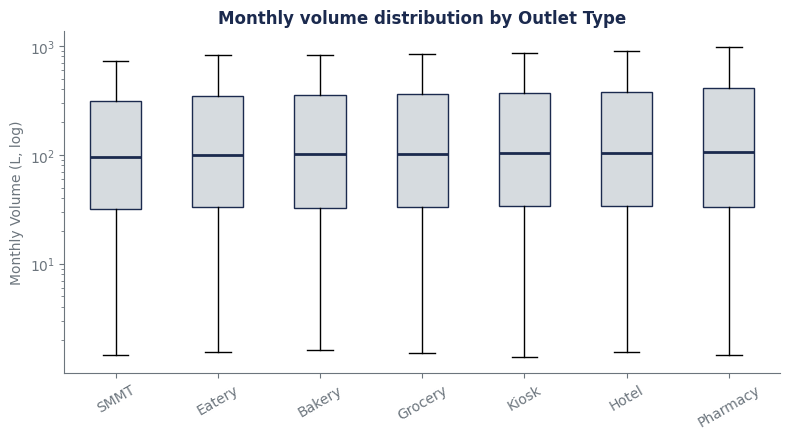

In [2]:
type_order = df.groupby("Outlet_Type")["Volume_Liters"].median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(8, 4.5))
bp = ax.boxplot(
    [df.loc[df["Outlet_Type"] == t, "Volume_Liters"] for t in type_order],
    tick_labels=type_order, vert=True, showfliers=False, patch_artist=True,
)
for box in bp["boxes"]:
    box.set(facecolor=LIGHT, edgecolor=NAVY)
for med in bp["medians"]:
    med.set(color=NAVY, linewidth=2)
ax.set_yscale("log")
ax.set_ylabel("Monthly Volume (L, log)")
ax.set_title("Monthly volume distribution by Outlet Type")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(FIG / "volume_by_outlet_type.png", dpi=150)
plt.show()

Spread is enormous — orders of magnitude. Hotels and Groceries sit higher than Kiosks/Pharmacies. Log scale is going to matter for the model.

## Eyeballing 20 random outlets for plateaus

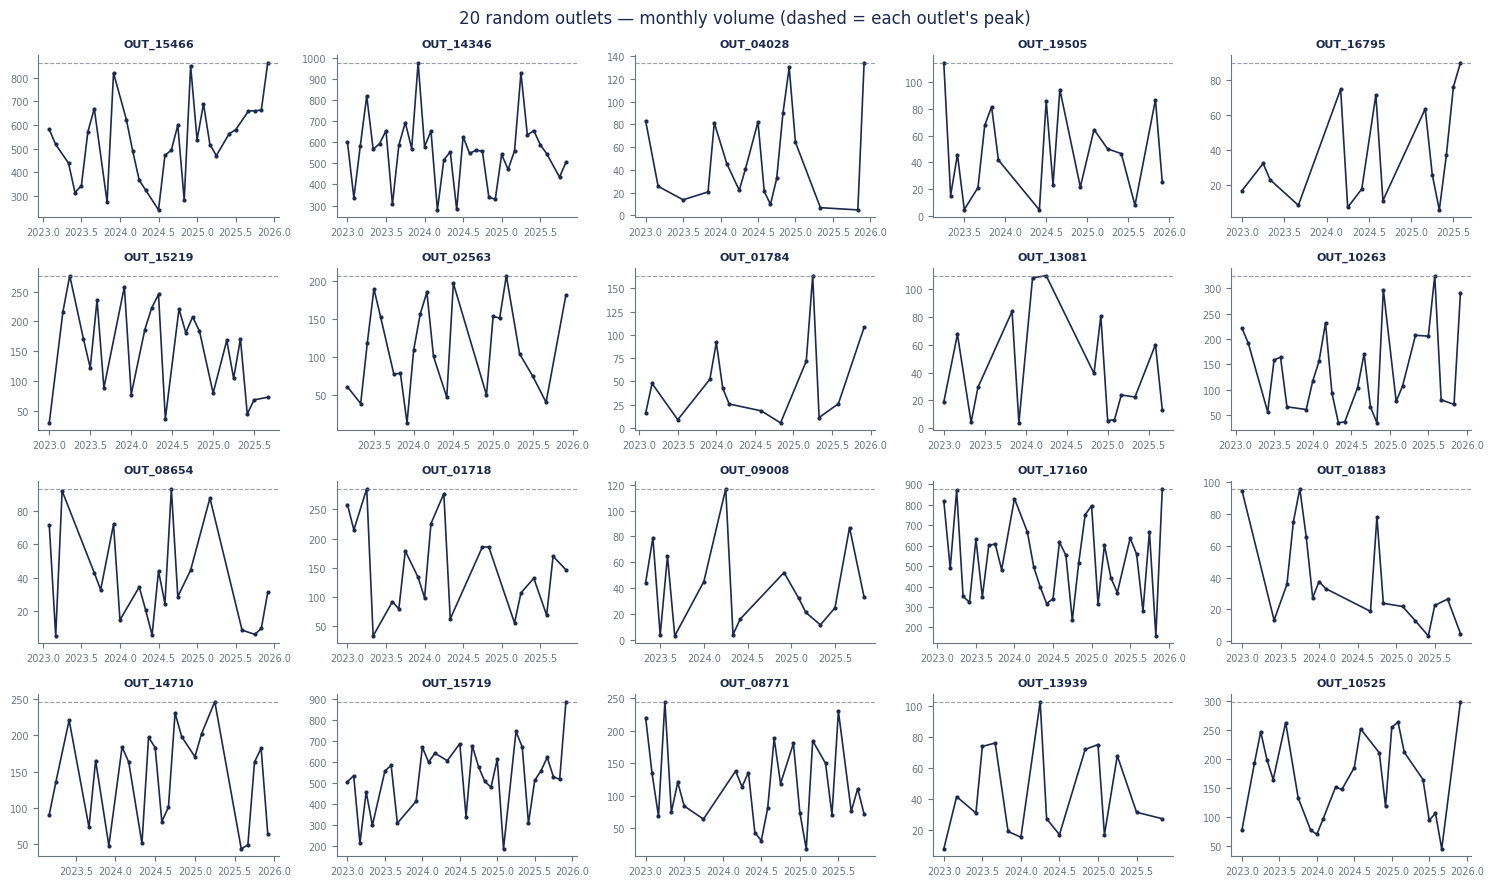

In [3]:
rng = np.random.default_rng(42)
sample_ids = rng.choice(monthly["Outlet_ID"].unique(), size=20, replace=False)
fig, axes = plt.subplots(4, 5, figsize=(15, 9))
for ax, oid in zip(axes.flat, sample_ids):
    sub = monthly[monthly["Outlet_ID"] == oid].sort_values(["Year", "Month"])
    t = sub["Year"] + (sub["Month"] - 1) / 12
    ax.plot(t, sub["Volume_Liters"], color=NAVY, marker="o", markersize=2, linewidth=1.2)
    ax.axhline(sub["Volume_Liters"].max(), color=GREY, linestyle="--", linewidth=0.8, alpha=0.7)
    ax.set_title(oid, fontsize=8)
    ax.tick_params(axis="both", labelsize=7)
fig.suptitle("20 random outlets — monthly volume (dashed = each outlet's peak)", color=NAVY)
fig.tight_layout()
fig.savefig(FIG / "random_outlet_trends.png", dpi=150)
plt.show()

Some outlets show clear repeated touches against their own peak — that's the censoring signal. Others are noisy with no obvious ceiling.

## Ceiling-hit rate per outlet

For each outlet: fraction of months where volume ≥ that outlet's peak × 0.98. High values suggest the outlet is supply-constrained.

In [4]:
peak = monthly.groupby("Outlet_ID")["Volume_Liters"].max().rename("peak")
m = monthly.merge(peak, on="Outlet_ID")
m["hit"] = m["Volume_Liters"] >= m["peak"] * 0.98
hit_rate = m.groupby("Outlet_ID")["hit"].mean()

print("> 30% hit rate:", int((hit_rate > 0.30).sum()), "outlets")
print("> 10% hit rate:", int((hit_rate > 0.10).sum()))
print("Median hit rate:", round(float(hit_rate.median()), 3))

> 30% hit rate: 0 outlets
> 10% hit rate: 766
Median hit rate: 0.053


Tight 2%-of-peak definition: almost no outlets cross the 30% mark. That's a problem — the constraint signal collapses if we require literal equality.

Decision: in `gold_features.py` we use **P95 × 0.98** instead of **peak × 0.98**. That gives a graded signal across most outlets while still flagging the heavily-capped ones.

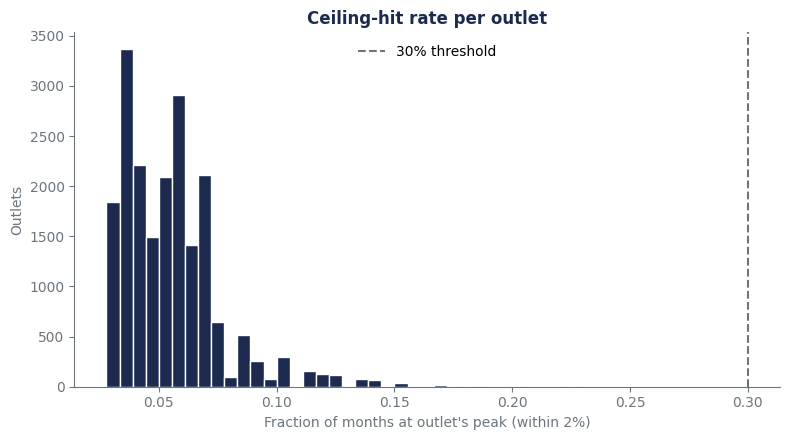

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(hit_rate, bins=40, color=NAVY, edgecolor="white")
ax.axvline(0.30, color=GREY, linestyle="--", linewidth=1.5, label="30% threshold")
ax.set_xlabel("Fraction of months at outlet's peak (within 2%)")
ax.set_ylabel("Outlets")
ax.set_title("Ceiling-hit rate per outlet")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG / "ceiling_hit_rate_hist.png", dpi=150)
plt.show()

## Per-distributor hit rate

If one distributor systematically supply-constrains its outlets, its mean hit rate should be visibly higher than others.

In [6]:
dist_hit = m.groupby("Distributor_ID")["hit"].mean().sort_values(ascending=False)
print(dist_hit.round(3))

Distributor_ID
DIST_S_01     0.054
DIST_C_03     0.053
DIST_S_02     0.053
DIST_C_02     0.052
DIST_C_01     0.052
DIST_NW_02    0.051
DIST_NW_01    0.051
DIST_W_03     0.051
DIST_W_01     0.050
DIST_W_02     0.050
Name: hit, dtype: float64


Range is 5.0% – 5.4%. Differences are tiny. No single distributor stands out as a supply bottleneck — censoring (where it exists) is an outlet-level phenomenon, not a distributor-level one.

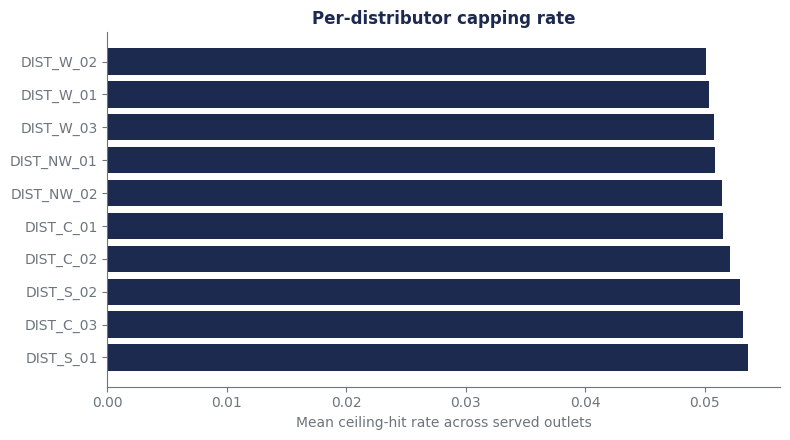

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(dist_hit.index, dist_hit.values, color=NAVY)
ax.set_xlabel("Mean ceiling-hit rate across served outlets")
ax.set_title("Per-distributor capping rate")
fig.tight_layout()
fig.savefig(FIG / "distributor_hit_rate.png", dpi=150)
plt.show()

## Seasonality empirical check

CLAUDE-md / spec proposed multipliers 1.15 / 1.00 / 0.85 for Favorable / Moderate / Un-Favorable. Let's check the actual data instead of trusting the proposal.

In [8]:
seas = pd.read_parquet(SILVER / "distributor_seasonality_clean.parquet")
joined = monthly.merge(seas, on=["Distributor_ID", "Year", "Month"])
joined["log_vol"] = np.log1p(joined["Volume_Liters"])
summary = joined.groupby("Seasonality_Index")["Volume_Liters"].agg(["mean", "count"]).round(1)
summary["pct_vs_moderate"] = ((summary["mean"] / summary.loc["Moderate", "mean"]) - 1) * 100
print(summary.round(1))

                    mean   count  pct_vs_moderate
Seasonality_Index                                
Favorable          367.4   93667             40.3
Moderate           261.9  310466              0.0
Un-Favorable       171.5   43429            -34.5


Reality: Favorable months are +40% (raw mean) or 1.44× (log-implied), Un-Favorable is −34% / 0.61×. Way more than the proposed ±15%.

Decision: use 1.30 / 1.00 / 0.70 — conservative pull-back from the empirical numbers, since Jan-2026 seasonality is not in the source data and we don't want to overshoot on extrapolated multipliers.

## Headline numbers (for the report)

In [9]:
print(f"Outlets:              {monthly['Outlet_ID'].nunique():,}")
print(f"Outlet-months:        {len(monthly):,}")
print(f"Median months active: {int(monthly.groupby('Outlet_ID').size().median())}")
print(f"Median monthly L:     {monthly['Volume_Liters'].median():.1f}")
print(f"Outlets w/ hit-rate > 30%: {int((hit_rate > 0.30).sum())}")
print(f"Highest dist hit rate: {dist_hit.index[0]} @ {dist_hit.iloc[0]*100:.1f}%")

Outlets:              20,000
Outlet-months:        447,562
Median months active: 21
Median monthly L:     101.3
Outlets w/ hit-rate > 30%: 0
Highest dist hit rate: DIST_S_01 @ 5.4%
